# Оптимизация гиперпараметров и black-box оптимизация


In [11]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel, ExpSineSquared
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

## black-box оптимизация

Представьте, что мы настраиваем модель, где один запуск обучения с кросс-валидацией занимает 10-20 минут. Тогда даже 50 неудачных попыток быстро превращаются в часы вычислений. При этом мы хотим, конечно же, получить как можно лучшие скоры и поэтому пытаемся подобрать наилучшие гиперпараметры для модели и обучения.
Формально мы решаем задачу

$\hat{x} = \arg\max_{x \in \mathcal{X}} f(x)$,

где $x$ — набор гиперпараметров, а $f(x)$ — качество модели на валидации.

Ключевая сложность в том, что $f(x)$ обычно:
- дорогая в вычислении,
- не имеет явного аналитического выражения,
- не предоставляет градиенты,
- содержит одновременно дискретные и непрерывные параметры,
- может быть шумной из-за стохастичности обучения и разбиений.

Поэтому классические градиентные методы здесь мало применимы напрямую: они требуют гладкой и доступной для дифференцирования функции, а в HPO мы видим только «черный ящик» с ответом после полного запуска пайплайна. Поэтому основаная цель состоит в том, чтобы найти сильную конфигурацию параметров при минимальном числе вызовов $f(x)$. Более формально, мы пытаемся минимизировать число итераций t, после которых мы можем гарантировать, что при параметрах $ \hat x_t: f(\hat x_t) - max(f) < \epsilon $

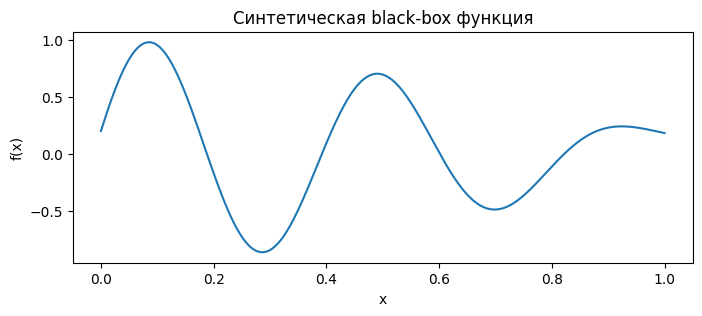

In [12]:
x = np.linspace(0, 1, 400)
y = np.sin(5 * np.pi * x) * (1 - x) + 0.2 * np.cos(13 * x)

plt.figure(figsize=(8, 3))
plt.plot(x, y)
plt.title("Синтетическая black-box функция")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

## Grid Search vs Random Search


Чаще всего первый выбор для подбора гиперпараметров - либо систематично проходить сетку, либо тратить тот же бюджет на случайные попытки.

`Grid Search` равномерно покрывает пространство параметров, но быстро страдает от проклятия размерности: при $d$ параметрах и $k$ значениях на ось требуется $k^d$ запусков. 

На практике бюджет обычно 20-40 запусков, поэтому полная сетка почти всегда слишком грубая или слишком дорогая.
`Random Search` при том же бюджете часто эффективнее, когда реально важны 1-2 параметра из многих: случайная выборка дает больше разных значений по каждой оси и повышает шанс быстро попасть в «рабочий» регион. К тому же, тогда можно задать распределения для каждой оси, чтобы лучше соответствовать смыслу параметров. 

Именно поэтому random search часто выступает сильным baseline, а не просто «наивным» методом. Однако он тоже может быть не тем, что хочется: либо может генерировать слишком похожие наблюдения, либо никогда не найти глобальный максимум.



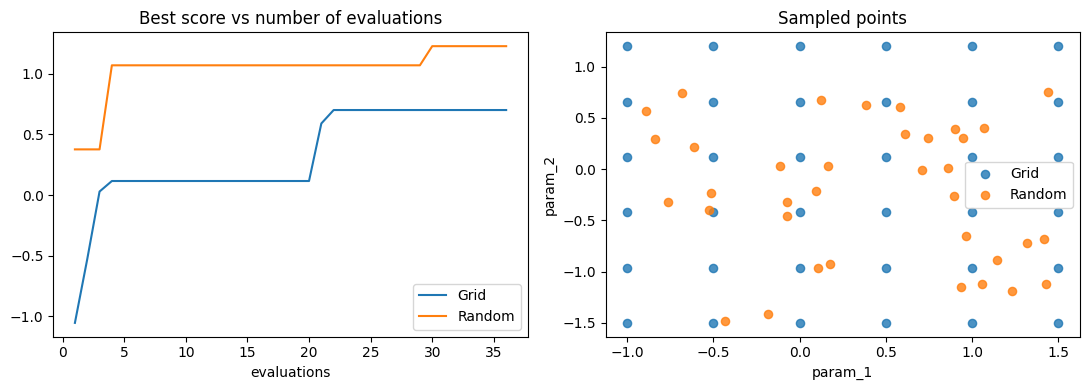

In [13]:
def score_surface(c: float, g: float) -> float:
    return 1.2 * np.exp(-((c - 0.75) ** 2) / 0.08) - 0.6 * (g + 0.2) ** 2 + 0.25 * np.sin(4 * c) * np.cos(3 * g)

budget = 36

grid_c = np.linspace(-1.0, 1.5, 6)
grid_g = np.linspace(-1.5, 1.2, 6)
grid_points = np.array([(c, g) for c in grid_c for g in grid_g])
grid_scores = np.array([score_surface(c, g) for c, g in grid_points])
grid_best = np.maximum.accumulate(grid_scores)

rng = np.random.default_rng(42)
rand_points = np.column_stack([
    rng.uniform(-1.0, 1.5, budget),
    rng.uniform(-1.5, 1.2, budget),
])
rand_scores = np.array([score_surface(c, g) for c, g in rand_points])
rand_best = np.maximum.accumulate(rand_scores)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(np.arange(1, budget + 1), grid_best[:budget], label="Grid")
axes[0].plot(np.arange(1, budget + 1), rand_best, label="Random")
axes[0].set_title("Best score vs number of evaluations")
axes[0].set_xlabel("evaluations")
axes[0].legend()

axes[1].scatter(grid_points[:budget, 0], grid_points[:budget, 1], s=35, alpha=0.8, label="Grid")
axes[1].scatter(rand_points[:, 0], rand_points[:, 1], s=35, alpha=0.8, label="Random")
axes[1].set_title("Sampled points")
axes[1].set_xlabel("param_1")
axes[1].set_ylabel("param_2")
axes[1].legend()

plt.tight_layout()
plt.show()

Минусы обоиъ методов в том, что они никогда не смотрят на предыдущие измерения. Можно, конечно, сначала пройтись по грубой сетке, а потом еще раз по уточненной, но этого все равно может быть недостаточно. Кроме того, хотелось бы комбинировать сразу и исследование потенциально "хороших" регионов (exploitation), и те регионы, где семплов для каких-то выводов еще недостаточно (exploration). Оптимальная стратегия должна комбинировать оба направления и при этом давать какой-то трейд-офф.

**Задание** Увеличьте размерность синтетической поверхности до 4 параметров и сравните деградацию Grid Search и Random Search при фиксированном бюджете. 

**Задание** Измените функцию так, чтобы только один параметр был действительно важным, и проверьте, как меняется разрыв между методами.

**Задание** Постройте кривые regret: $r_t = f(x^*) - \max_{i \le t} f(x_i)$.

# Bayesian optimization

Учитывая ограниение по числу попыток померять функцию, обычно используется итеративная процедура - построить суррогатную модель функции, на основе этой модели оценить потенциал точки в текущей сетке, выбрать новую точку для проверки. Как она выбирается:
1. Для каждого кандидата считаем  функцию стоимости (aquisition function).
2. Выбирается $x_{t+1}=\arg\max_x \alpha(x)$.

Далее вычисляется значение функции в $x_{t+1}$, добавляется наблюдение в данные и обновляется суррогатная модель .

Таким образом, байесовская оптимизация состоит из двух компонент: 
- вероятностной модели функции
- функции ценности (acquisition function)

Далее мы рассмотрим оба этих компонента.

##  Gaussian Processes 

Гауссовский процесс  (GP) как раз позволяют балансировать exploration и exploitation: он одновременно дает
- ожидаемое значение функции $\mu_t(x)$,
- и меру неуверенности $\sigma_t(x)$ в этой оценке.

Это критично для black-box оптимизации: мы пытаемся строить вероятностную модель, которая "будет знать" и что $x_1$ будет хорошим семплом, так как ожидаемое значение функции большое, и что $x_1$ будет хорошим семплом, так как в этом месте большая неопределенность.

Из чего он состоит:

**Априорное распределение (prior).** GP задаёт распределение над функциями $f: \mathcal{X} \to \mathbb{R}$: $f(x) \sim \mathcal{GP}(m(x), k(x, x'))$, где $m$ — среднее (часто $m \equiv 0$), а $k$ — ковариационная функция (ядро), возвращающая похожесть (близость) двух точек. Иными словами:
$$\mathbb{E}[f(\mathbf{x})] = m(\mathbf{x})$$
$$\mathbb{E}[(f(\mathbf{x})-m(\mathbf{x}))(f(\mathbf{x}')-m(\mathbf{x}'))] = k(\mathbf{x}, \mathbf{x}').$$

Для любого конечного набора входов $X = (x_1,\ldots,x_n)^\top$ вектор значений $f(X) = (f(x_1),\ldots,f(x_n))^\top$ априорно гауссов:
 
$f(X) \sim \mathcal{N}(m(X), K(X,X)), \quad K_{ij} = k(x_i, x_j).$

Ядро задаёт структурные предположения до наблюдения данных (kernel prior): оно определяет, при каких расстояниях между входами значения $f(x)$ и $f(x')$ сильно коррелируют и насколько «типичные» траектории гладкие или периодические. Ниже $r=\|x-x'\|$ (евклидово расстояние в масштабированных координатах), множитель $\sigma^2$ часто задаётся через `ConstantKernel` в sklearn.

- `RBF` (radial basis / squared exponential):
$k_{\mathrm{RBF}}(x,x')=\sigma^2\exp\left(-\frac{r^2}{2\ell^2}\right)$.

- `Matérn`. Общая стационарная форма:
$k_{\mathrm{Matérn}}(x,x')=\sigma^2\,\frac{2^{1-\nu}}{\Gamma(\nu)}\left(\frac{\sqrt{2\nu}\,r}{\ell}\right)^{\nu}K_{\nu}\!\left(\frac{\sqrt{2\nu}\,r}{\ell}\right)$,
где $K_{\nu}$ — модифицированная функция Бесселя второго рода; при $\nu\to\infty$ ядро стремится к RBF с тем же $\ell$.
Для $\nu \in\{0.5,1.5,2.5\}$ ($r=\|x-x'\|$):
  - $ \nu=\tfrac12:\quad k=\sigma^2\exp\left(-\frac{r}{\ell}\right)$;
  - $ \nu=\tfrac32:\quad k=\sigma^2\left(1+\frac{\sqrt{3}\,r}{\ell}\right)\exp\left(-\frac{\sqrt{3}\,r}{\ell}\right)$;
  - $ \nu=\tfrac52:\quad k=\sigma^2\left(1+\frac{\sqrt{5}\,r}{\ell}+\frac{5r^2}{3\ell^2}\right)\exp\left(-\frac{\sqrt{5}\,r}{\ell}\right)$.

- `RationalQuadratic`. Обозначим $d^2=\|x-x'\|^2$:
$k_{\mathrm{RQ}}(x,x')=\sigma^2\left(1+\frac{d^2}{2\alpha\ell^2}\right)^{-\alpha}$.
При разных $\alpha$ — «мультимасштабное» затухание корреляций (в пределе смесь RBF-ядер с разными $\ell$).

- Периодическое (для $d>1$):
$k_{\mathrm{per}}(x,x')=\sigma^2\exp\left(-\frac{2\sin^2(\pi r/p)}{\ell^2}\right)$.

В следующих кодовых ячейках: общая настройка сетки и функция `gram_imshow` для матрицы $K(X,X)$; затем отдельные ячейки для RBF (SE), Matérn при $\nu\in\{0.5,1.5,2.5\}$, RationalQuadratic и ExpSineSquared. В каждой ячейке три панели: тепловая карта $K(X,X)$ априорного ядра на сетке, семплы априорных траекторий и предсказательный апостериор (семплы, среднее и доверительная полоса).

**Наблюдения и правдоподобие.** В регрессии часто $y_i = f(x_i) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, \sigma_n^2)$ независимо. Совместное распределение $(f(X), y)$ остаётся гауссовым, поэтому байесовское обновление даёт гауссовский постериор над значениями $f$ на сетке.

**Постериор и предсказание.** После $\mathcal{D}_t = \{(x_i, y_i)\}_{i=1}^t$ условное распределение $f(X_*) \mid \mathcal{D}_t$ на конечной тестовой сетке $X_*$ — многомерное нормальное. В одной точке $x_*$ маргинальное предсказание снова нормальное; ниже — формулы для среднего $\mu_t(x_*)$ и дисперсии $\sigma_t^2(x_*)$.

При наблюдениях $\mathcal{D}_t = \{(x_i, y_i)\}_{i=1}^t$ предсказание в точке $x_*$ задается нормальным распределением:

$ p(f_* \mid \mathcal{D}_t) = \mathcal{N}(\mu_t(x_*), \sigma_t^2(x_*)) $.

При шуме $\sigma_n^2$:

$\mu_t(x_*) = K(x_*, X) [K(X, X) + \sigma_n^2 I]^{-1} y,$

$\sigma_t^2(x_*) = K(x_*, x_*) - K(x_*, X)[K(X, X) + \sigma_n^2 I]^{-1}K(X, x_*).$

**Семплирование из априорного распределения.** На сетке $x_1,\ldots,x_n$ строим $K = K(X,X)$, добавляем к диагонали малый джиттер $\varepsilon > 0$ и разложение Холецкого $K + \varepsilon I = L L^\top$. Тогда

$f = m + L z, \quad z \sim \mathcal{N}(0, I)$

даёт один семпл вектора значений $f$ на сетке, согласованный с априорным GP.

**Семплирование из постериора.** На той же сетке можно семплировать из $\mathcal{N}(\mu_*, \Sigma_*)$, где $\mu_*$ — вектор постериорных средних на сетке, $\Sigma_*$ — постериорная ковариация (гауссовская условная формула). 
Практическая интерпретация:
- маленькая $\sigma_t(x)$: регион уже хорошо изучен;
- большая $\sigma_t(x)$: регион мало изучен, там возможны как провалы, так и неожиданные улучшения.


In [14]:
x_grid_prior = np.linspace(0, 1, 160).reshape(-1, 1)


def true_synth(x: np.ndarray) -> np.ndarray:
    return np.sin(4 * np.pi * x) * (1 - x)


def gram_imshow(ax, K_mat: np.ndarray, title: str) -> None:
    im = ax.imshow(
        K_mat,
        origin="lower",
        extent=[0, 1, 0, 1],
        aspect="auto",
        cmap="viridis",
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title)
    ax.set_xlabel("$x_i$")
    ax.set_ylabel("$x_j$")


X_demo = np.array([[0.08], [0.28], [0.52], [0.79]])
y_demo = true_synth(X_demo[:, 0])
jitter = 1e-8
n_draw = 6
alpha_gpr = 1e-10
rng_gp = np.random.default_rng(42)
z_prior = rng_gp.standard_normal((x_grid_prior.shape[0], n_draw))
y_synth = true_synth(x_grid_prior[:, 0])


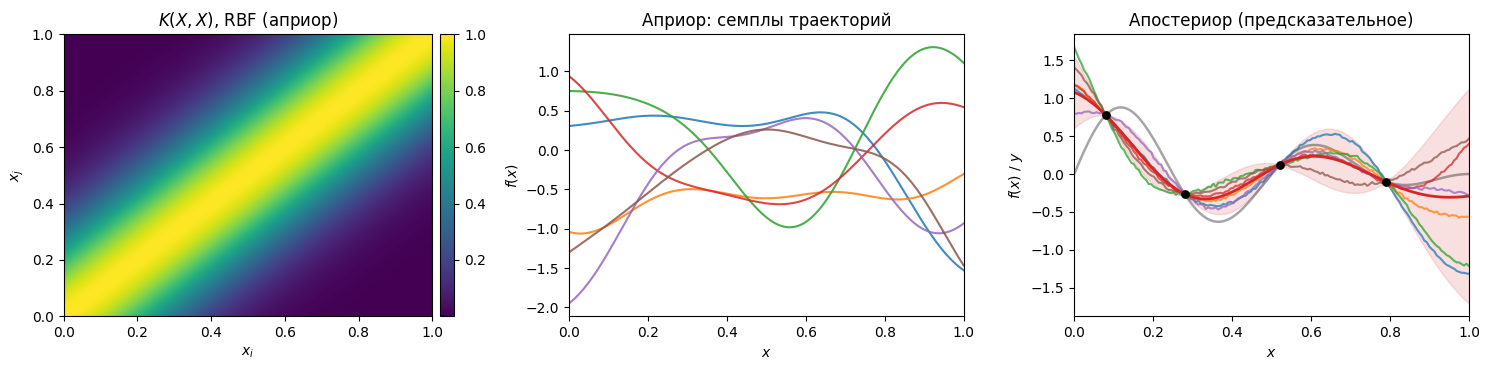

In [15]:
ell_rbf = 0.22
noise_rbf = 1e-4
k_prior_rbf = RBF(length_scale=ell_rbf)
k_post_rbf = (
    ConstantKernel(1.0, constant_value_bounds="fixed")
    * RBF(length_scale=ell_rbf, length_scale_bounds="fixed")
    + WhiteKernel(noise_level=noise_rbf, noise_level_bounds="fixed")
)
K_pr = k_prior_rbf(x_grid_prior)
L_pr = np.linalg.cholesky(K_pr + jitter * np.eye(K_pr.shape[0]))
prior_paths_rbf = L_pr @ z_prior
gp_rbf = GaussianProcessRegressor(
    kernel=k_post_rbf, alpha=alpha_gpr, normalize_y=False, optimizer=None, random_state=42
)
gp_rbf.fit(X_demo, y_demo)
mu_rbf, cov_rbf = gp_rbf.predict(x_grid_prior, return_cov=True)
cov_rbf = cov_rbf + 1e-8 * np.eye(cov_rbf.shape[0])
post_paths_rbf = rng_gp.multivariate_normal(mu_rbf, cov_rbf, size=n_draw).T
std_rbf = np.sqrt(np.maximum(np.diag(cov_rbf), 0.0))

fig_rbf, axes_rbf = plt.subplots(1, 3, figsize=(15.0, 3.8))
gram_imshow(axes_rbf[0], K_pr, "$K(X,X)$, RBF (априор)")
axes_rbf[1].plot(x_grid_prior[:, 0], prior_paths_rbf, alpha=0.85)
axes_rbf[1].set_title("Априор: семплы траекторий")
axes_rbf[1].set_xlim(0, 1)
axes_rbf[1].set_xlabel("$x$")
axes_rbf[1].set_ylabel("$f(x)$")
axes_rbf[2].plot(x_grid_prior[:, 0], y_synth, color="black", alpha=0.35, linewidth=1.8)
axes_rbf[2].plot(x_grid_prior[:, 0], post_paths_rbf, alpha=0.75)
axes_rbf[2].plot(x_grid_prior[:, 0], mu_rbf, color="tab:red", linewidth=2.0)
axes_rbf[2].fill_between(
    x_grid_prior[:, 0],
    mu_rbf - 1.96 * std_rbf,
    mu_rbf + 1.96 * std_rbf,
    color="tab:red",
    alpha=0.14,
)
axes_rbf[2].scatter(X_demo[:, 0], y_demo, color="black", s=28, zorder=5)
axes_rbf[2].set_title("Апостериор (предсказательное)")
axes_rbf[2].set_xlim(0, 1)
axes_rbf[2].set_xlabel("$x$")
axes_rbf[2].set_ylabel("$f(x)$ / $y$")
plt.tight_layout()
plt.show()


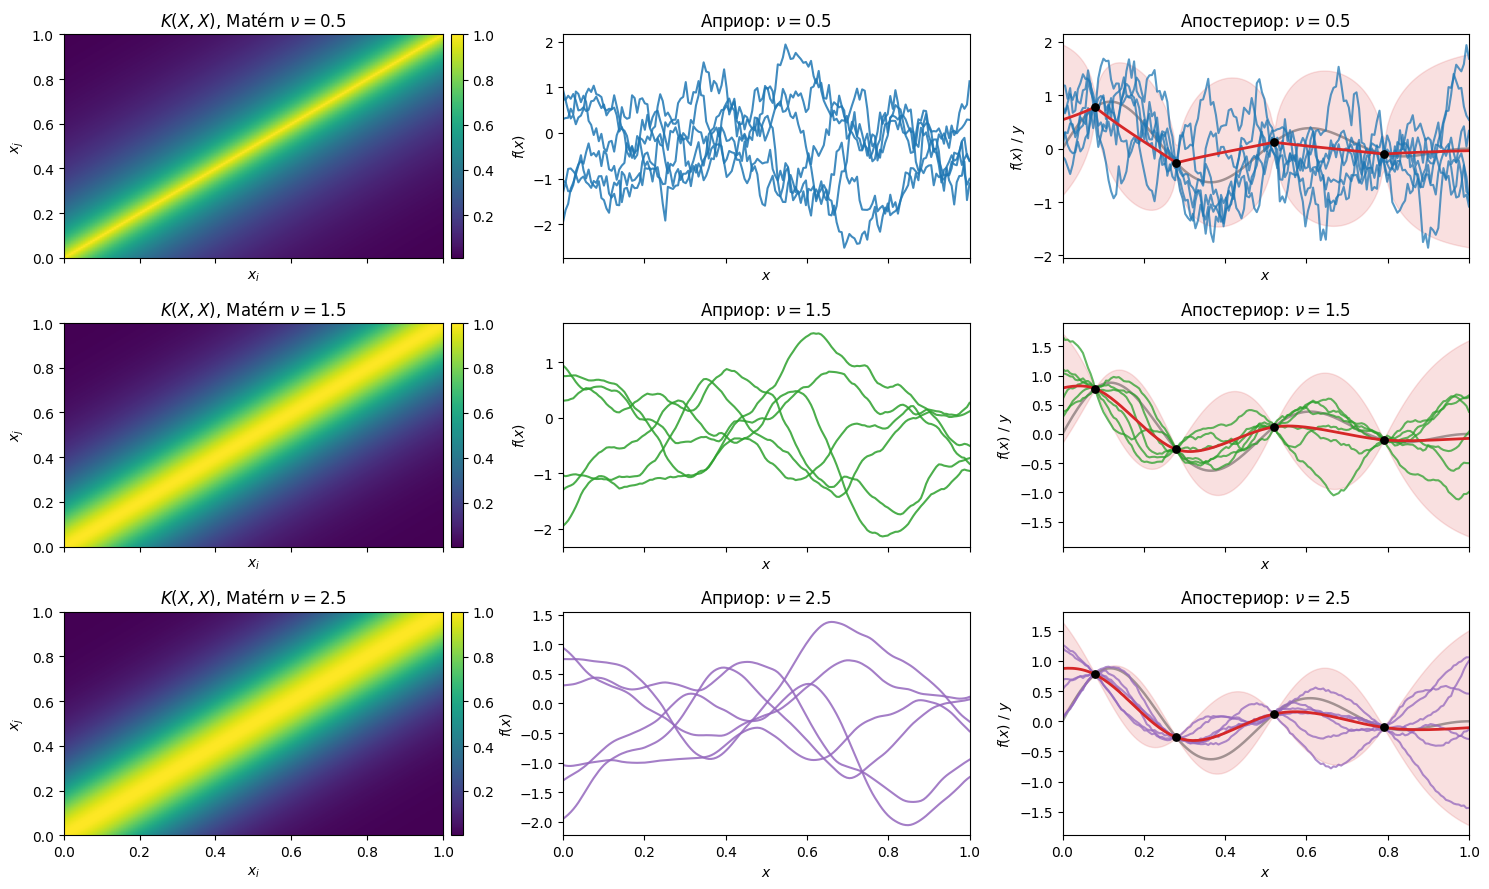

In [16]:
ell_matern = 0.22
noise_matern = 1e-4
nus_matern = (0.5, 1.5, 2.5)
colors_matern = ("tab:blue", "tab:green", "tab:purple")

fig_m, axes_m = plt.subplots(len(nus_matern), 3, figsize=(15.0, 9.0), sharex="col")
for row, (nu, c) in enumerate(zip(nus_matern, colors_matern)):
    km = Matern(length_scale=ell_matern, nu=nu)
    K_m = km(x_grid_prior)
    gram_imshow(axes_m[row, 0], K_m, f"$K(X,X)$, Matérn $\\nu={nu}$")
    L_m = np.linalg.cholesky(K_m + jitter * np.eye(K_m.shape[0]))
    prior_m = L_m @ z_prior
    axes_m[row, 1].plot(x_grid_prior[:, 0], prior_m, color=c, alpha=0.85)
    axes_m[row, 1].set_title(f"Априор: $\\nu={nu}$")
    axes_m[row, 1].set_xlim(0, 1)
    axes_m[row, 1].set_xlabel("$x$")
    axes_m[row, 1].set_ylabel("$f(x)$")
    k_post_m = (
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * Matern(length_scale=ell_matern, nu=nu, length_scale_bounds="fixed")
        + WhiteKernel(noise_level=noise_matern, noise_level_bounds="fixed")
    )
    gp_m = GaussianProcessRegressor(
        kernel=k_post_m, alpha=alpha_gpr, normalize_y=False, optimizer=None, random_state=42
    )
    gp_m.fit(X_demo, y_demo)
    mu_m, cov_m = gp_m.predict(x_grid_prior, return_cov=True)
    cov_m = cov_m + 1e-8 * np.eye(cov_m.shape[0])
    post_m = rng_gp.multivariate_normal(mu_m, cov_m, size=n_draw).T
    std_m = np.sqrt(np.maximum(np.diag(cov_m), 0.0))
    axes_m[row, 2].plot(x_grid_prior[:, 0], y_synth, color="black", alpha=0.35, linewidth=1.8)
    axes_m[row, 2].plot(x_grid_prior[:, 0], post_m, color=c, alpha=0.75)
    axes_m[row, 2].plot(x_grid_prior[:, 0], mu_m, color="tab:red", linewidth=2.0)
    axes_m[row, 2].fill_between(
        x_grid_prior[:, 0],
        mu_m - 1.96 * std_m,
        mu_m + 1.96 * std_m,
        color="tab:red",
        alpha=0.14,
    )
    axes_m[row, 2].scatter(X_demo[:, 0], y_demo, color="black", s=28, zorder=5)
    axes_m[row, 2].set_title(f"Апостериор: $\\nu={nu}$")
    axes_m[row, 2].set_xlim(0, 1)
    axes_m[row, 2].set_xlabel("$x$")
    axes_m[row, 2].set_ylabel("$f(x)$ / $y$")
plt.tight_layout()
plt.show()


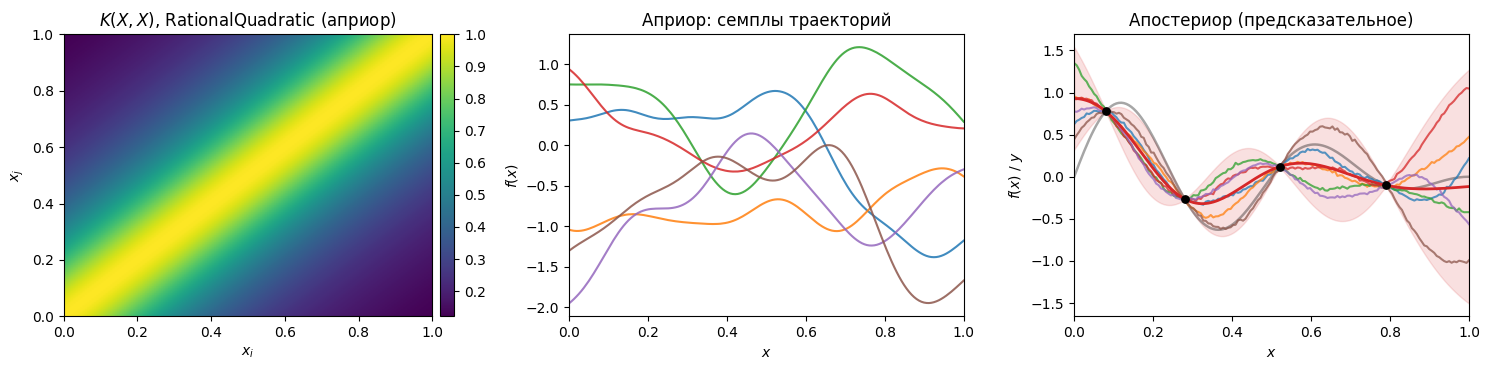

In [17]:
ell_rq = 0.22
alpha_rq = 0.8
noise_rq = 1e-4
k_prior_rq = RationalQuadratic(length_scale=ell_rq, alpha=alpha_rq)
k_post_rq = (
    ConstantKernel(1.0, constant_value_bounds="fixed")
    * RationalQuadratic(
        length_scale=ell_rq,
        alpha=alpha_rq,
        length_scale_bounds="fixed",
        alpha_bounds="fixed",
    )
    + WhiteKernel(noise_level=noise_rq, noise_level_bounds="fixed")
)
K_rq = k_prior_rq(x_grid_prior)
L_rq = np.linalg.cholesky(K_rq + jitter * np.eye(K_rq.shape[0]))
prior_paths_rq = L_rq @ z_prior
gp_rq = GaussianProcessRegressor(
    kernel=k_post_rq, alpha=alpha_gpr, normalize_y=False, optimizer=None, random_state=42
)
gp_rq.fit(X_demo, y_demo)
mu_rq, cov_rq = gp_rq.predict(x_grid_prior, return_cov=True)
cov_rq = cov_rq + 1e-8 * np.eye(cov_rq.shape[0])
post_paths_rq = rng_gp.multivariate_normal(mu_rq, cov_rq, size=n_draw).T
std_rq = np.sqrt(np.maximum(np.diag(cov_rq), 0.0))

fig_rq, axes_rq = plt.subplots(1, 3, figsize=(15.0, 3.8))
gram_imshow(axes_rq[0], K_rq, "$K(X,X)$, RationalQuadratic (априор)")
axes_rq[1].plot(x_grid_prior[:, 0], prior_paths_rq, alpha=0.85)
axes_rq[1].set_title("Априор: семплы траекторий")
axes_rq[1].set_xlim(0, 1)
axes_rq[1].set_xlabel("$x$")
axes_rq[1].set_ylabel("$f(x)$")
axes_rq[2].plot(x_grid_prior[:, 0], y_synth, color="black", alpha=0.35, linewidth=1.8)
axes_rq[2].plot(x_grid_prior[:, 0], post_paths_rq, alpha=0.75)
axes_rq[2].plot(x_grid_prior[:, 0], mu_rq, color="tab:red", linewidth=2.0)
axes_rq[2].fill_between(
    x_grid_prior[:, 0],
    mu_rq - 1.96 * std_rq,
    mu_rq + 1.96 * std_rq,
    color="tab:red",
    alpha=0.14,
)
axes_rq[2].scatter(X_demo[:, 0], y_demo, color="black", s=28, zorder=5)
axes_rq[2].set_title("Апостериор (предсказательное)")
axes_rq[2].set_xlim(0, 1)
axes_rq[2].set_xlabel("$x$")
axes_rq[2].set_ylabel("$f(x)$ / $y$")
plt.tight_layout()
plt.show()


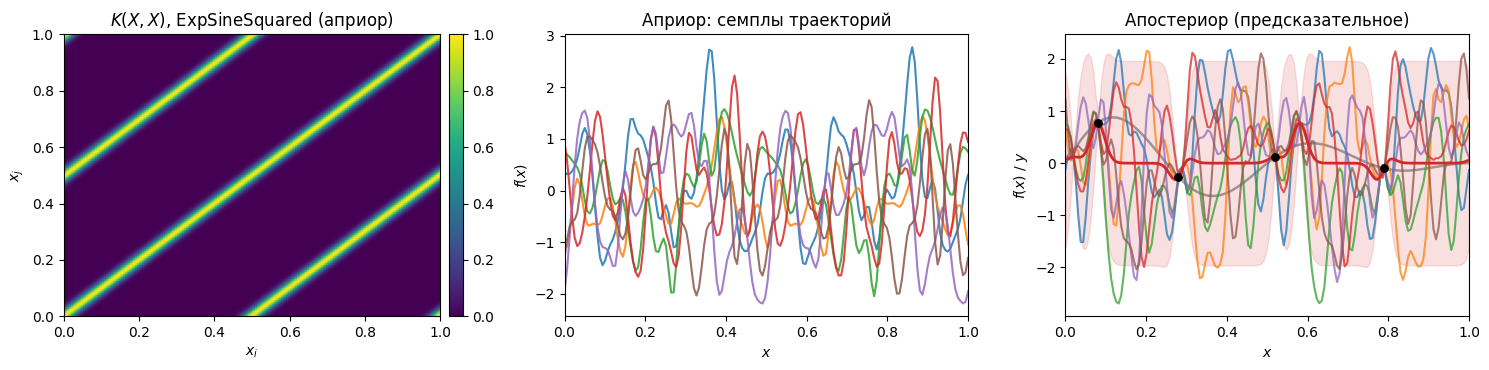

In [18]:
ell_per = 0.22
period_per = 0.5
noise_per = 1e-4
k_prior_per = ExpSineSquared(length_scale=ell_per, periodicity=period_per)
k_post_per = (
    ConstantKernel(1.0, constant_value_bounds="fixed")
    * ExpSineSquared(
        length_scale=ell_per,
        periodicity=period_per,
        length_scale_bounds="fixed",
        periodicity_bounds="fixed",
    )
    + WhiteKernel(noise_level=noise_per, noise_level_bounds="fixed")
)
K_per = k_prior_per(x_grid_prior)
L_per = np.linalg.cholesky(K_per + jitter * np.eye(K_per.shape[0]))
prior_paths_per = L_per @ z_prior
gp_per = GaussianProcessRegressor(
    kernel=k_post_per, alpha=alpha_gpr, normalize_y=False, optimizer=None, random_state=42
)
gp_per.fit(X_demo, y_demo)
mu_per, cov_per = gp_per.predict(x_grid_prior, return_cov=True)
cov_per = cov_per + 1e-8 * np.eye(cov_per.shape[0])
post_paths_per = rng_gp.multivariate_normal(mu_per, cov_per, size=n_draw).T
std_per = np.sqrt(np.maximum(np.diag(cov_per), 0.0))

fig_per, axes_per = plt.subplots(1, 3, figsize=(15.0, 3.8))
gram_imshow(axes_per[0], K_per, "$K(X,X)$, ExpSineSquared (априор)")
axes_per[1].plot(x_grid_prior[:, 0], prior_paths_per, alpha=0.85)
axes_per[1].set_title("Априор: семплы траекторий")
axes_per[1].set_xlim(0, 1)
axes_per[1].set_xlabel("$x$")
axes_per[1].set_ylabel("$f(x)$")
axes_per[2].plot(x_grid_prior[:, 0], y_synth, color="black", alpha=0.35, linewidth=1.8)
axes_per[2].plot(x_grid_prior[:, 0], post_paths_per, alpha=0.75)
axes_per[2].plot(x_grid_prior[:, 0], mu_per, color="tab:red", linewidth=2.0)
axes_per[2].fill_between(
    x_grid_prior[:, 0],
    mu_per - 1.96 * std_per,
    mu_per + 1.96 * std_per,
    color="tab:red",
    alpha=0.14,
)
axes_per[2].scatter(X_demo[:, 0], y_demo, color="black", s=28, zorder=5)
axes_per[2].set_title("Апостериор (предсказательное)")
axes_per[2].set_xlim(0, 1)
axes_per[2].set_xlabel("$x$")
axes_per[2].set_ylabel("$f(x)$ / $y$")
plt.tight_layout()
plt.show()


Можем посмотреть, как повлияют разные ядра на предсказания:

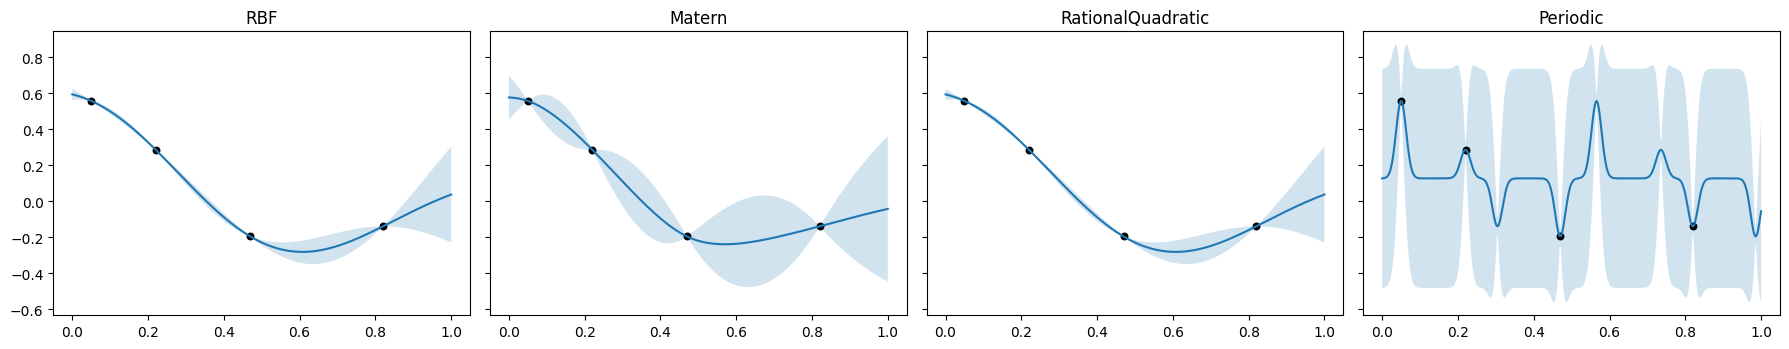

In [19]:
train_x_a = 0.05
train_x_b = 0.22
train_x_c = 0.47
train_x_d = 0.82
X_train_gp = np.array([[train_x_a], [train_x_b], [train_x_c], [train_x_d]])
y_train_gp = np.sin(4 * np.pi * X_train_gp[:, 0]) * (1 - X_train_gp[:, 0])

x_grid_lo = 0.0
x_grid_hi = 1.0
n_grid_gp = 400
X_grid_gp = np.linspace(x_grid_lo, x_grid_hi, n_grid_gp).reshape(-1, 1)

ell_mean_ci_rbf = 0.18
ell_mean_ci_matern = 0.2
nu_mean_ci_matern = 1.5
ell_mean_ci_rq = 0.2
alpha_mean_ci_rq = 0.8
ell_mean_ci_per = 0.2
period_mean_ci = 0.5
noise_mean_ci = 1e-4

kernels = {
    "RBF": ConstantKernel(1.0) * RBF(length_scale=ell_mean_ci_rbf) + WhiteKernel(noise_level=noise_mean_ci),
    "Matern": ConstantKernel(1.0) * Matern(length_scale=ell_mean_ci_matern, nu=nu_mean_ci_matern) + WhiteKernel(noise_level=noise_mean_ci),
    "RationalQuadratic": ConstantKernel(1.0) * RationalQuadratic(length_scale=ell_mean_ci_rq, alpha=alpha_mean_ci_rq) + WhiteKernel(noise_level=noise_mean_ci),
    "Periodic": ConstantKernel(1.0) * ExpSineSquared(length_scale=ell_mean_ci_per, periodicity=period_mean_ci) + WhiteKernel(noise_level=noise_mean_ci),
}

fig_w = 18.0
fig_h = 3.6
fig, axes = plt.subplots(1, 4, figsize=(fig_w, fig_h), sharey=True)
for ax, (name, kernel) in zip(axes, kernels.items()):
    gp_model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42)
    gp_model.fit(X_train_gp, y_train_gp)
    mu, std = gp_model.predict(X_grid_gp, return_std=True)
    ax.plot(X_grid_gp[:, 0], mu)
    ax.fill_between(X_grid_gp[:, 0], mu - 1.96 * std, mu + 1.96 * std, alpha=0.2)
    ax.scatter(X_train_gp[:, 0], y_train_gp, color="black", s=22)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Acquisition function

На каждом шаге байесовской оптимизации сначала строится GP-постериор, то есть функции $\mu_t(x)$ и $\sigma_t(x)$. Затем acquisition-функция преобразует их в критерий выбора новой точки. Разные стратегии могут выбирать разные $x_{t+1}$ даже при одном и том же GP-постериоре, балансируя exploration и exploitation.

Популярные acquisition-функции:

`UCB`:
$$a_{\text{UCB}}(x)=\mu_t(x)+\sqrt{\beta}\,\sigma_t(x)$$
 `UCB` является наиболее простой - она линейно добавляет бонус за неопределенность к среднему прогнозу, либо отдавая предпочтение точкам с наибольшим средним, либо с наибольшей неопреленностью. Чем больше $\beta$, тем сильнее стратегия смещается в сторону exploration. При меньшем $\beta$ поведение становится более exploit-ориентированным.


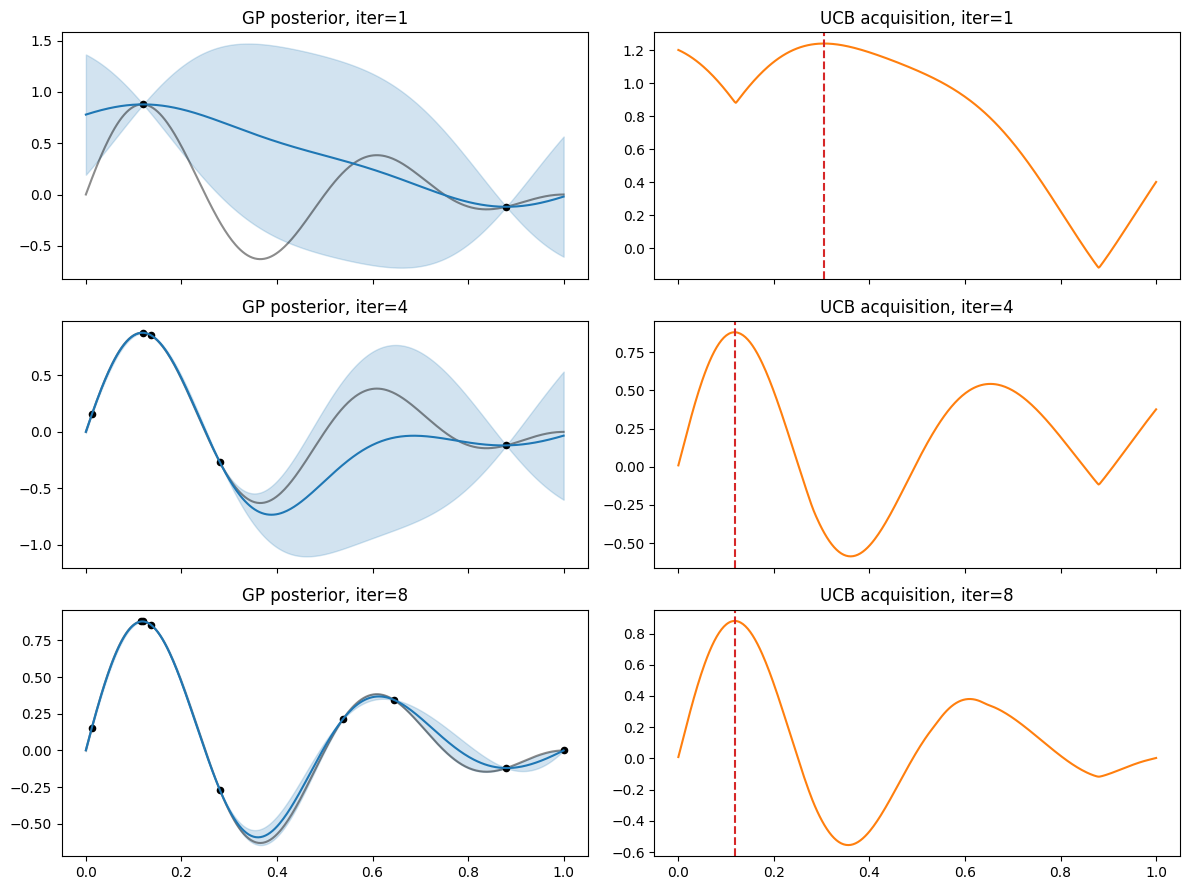

In [20]:
def true_bo_target(x: np.ndarray) -> np.ndarray:
    return np.sin(4 * np.pi * x) * (1 - x)


def acquisition_ucb(mu: np.ndarray, std: np.ndarray, beta: float) -> np.ndarray:
    return mu + np.sqrt(beta) * std


def acquisition_pi(mu: np.ndarray, std: np.ndarray, f_best: float, xi: float, eps: float) -> np.ndarray:
    sigma = std + eps
    z = (mu - f_best - xi) / sigma
    return norm.cdf(z)


def acquisition_ei(mu: np.ndarray, std: np.ndarray, f_best: float, xi: float, eps: float) -> np.ndarray:
    sigma = std + eps
    imp = mu - f_best - xi
    z = imp / sigma
    return imp * norm.cdf(z) + sigma * norm.pdf(z)


xi_acq = 0.01
beta_ucb = 2.0
eps_acq = 1e-9
x_grid = np.linspace(0.0, 1.0, 400).reshape(-1, 1)
y_true = true_bo_target(x_grid[:, 0])
kernel_bo = (
    ConstantKernel(1.0, constant_value_bounds="fixed")
    * RBF(length_scale=0.18, length_scale_bounds="fixed")
    + WhiteKernel(noise_level=1e-5, noise_level_bounds="fixed")
)
gp_bo = GaussianProcessRegressor(
    kernel=kernel_bo, normalize_y=True, random_state=42, optimizer=None
)
X_obs = np.array([[0.12], [0.88]])
y_obs = true_bo_target(X_obs[:, 0])
snapshots = []
for t in range(8):
    gp_bo.fit(X_obs, y_obs)
    mu_t, std_t = gp_bo.predict(x_grid, return_std=True)
    f_best = float(np.max(y_obs))
    acq_ucb = acquisition_ucb(mu_t, std_t, beta_ucb)
    acq_pi = acquisition_pi(mu_t, std_t, f_best, xi_acq, eps_acq)
    acq_ei = acquisition_ei(mu_t, std_t, f_best, xi_acq, eps_acq)
    snapshots.append(
        {
            "x_seen": X_obs.copy(),
            "y_seen": y_obs.copy(),
            "mu": mu_t,
            "std": std_t,
            "acq_ucb": acq_ucb,
            "acq_pi": acq_pi,
            "acq_ei": acq_ei,
        }
    )
    if t == 7:
        break
    x_next = float(x_grid[np.argmax(acq_ei), 0])
    X_obs = np.vstack([X_obs, np.array([[x_next]])])
    y_new = true_bo_target(np.array([x_next]))
    y_obs = np.concatenate([y_obs, y_new])

steps_to_show = [0, 3, 7]
fig, axes = plt.subplots(len(steps_to_show), 2, figsize=(12, 9), sharex=True)
for row, step in enumerate(steps_to_show):
    snap = snapshots[step]
    x_seen = snap["x_seen"]
    y_seen = snap["y_seen"]
    mu = snap["mu"]
    std = snap["std"]
    acq = snap["acq_ucb"]
    axes[row, 0].plot(x_grid[:, 0], y_true, color="black", alpha=0.45)
    axes[row, 0].plot(x_grid[:, 0], mu, color="tab:blue")
    axes[row, 0].fill_between(x_grid[:, 0], mu - 1.96 * std, mu + 1.96 * std, color="tab:blue", alpha=0.2)
    axes[row, 0].scatter(x_seen[:, 0], y_seen, color="black", s=20)
    axes[row, 0].set_title(f"GP posterior, iter={step + 1}")
    axes[row, 1].plot(x_grid[:, 0], acq, color="tab:orange")
    axes[row, 1].axvline(x_grid[np.argmax(acq), 0], color="tab:red", linestyle="--")
    axes[row, 1].set_title(f"UCB acquisition, iter={step + 1}")
plt.tight_layout()
plt.show()



`PI`: Обычно следующая точка выбирается как $argmax(\alpha(x))$, соответственно $argmax(P(f(x) \geq (f(x^+) + \xi)))$ соответствует CDF суррогатного постериора. Таким образом: 
$$a_{\text{PI}}(x)=\Phi\!\left(\frac{\mu_t(x)-f(x^+)-\xi}{\sigma_t(x)}\right)$$
`PI` максимизирует вероятность улучшить текущий лучший результат $f(x^+)$. Этот критерий часто выбирает точки с высокой вероятностью небольшого улучшения. Параметр $\xi$ повышает порог улучшения и усиливает exploration. При этом мы никак не учитываем насколько большим будет улучшение, и часто мы можем давать больше внимания точкам, где улучшение будет небольшим.



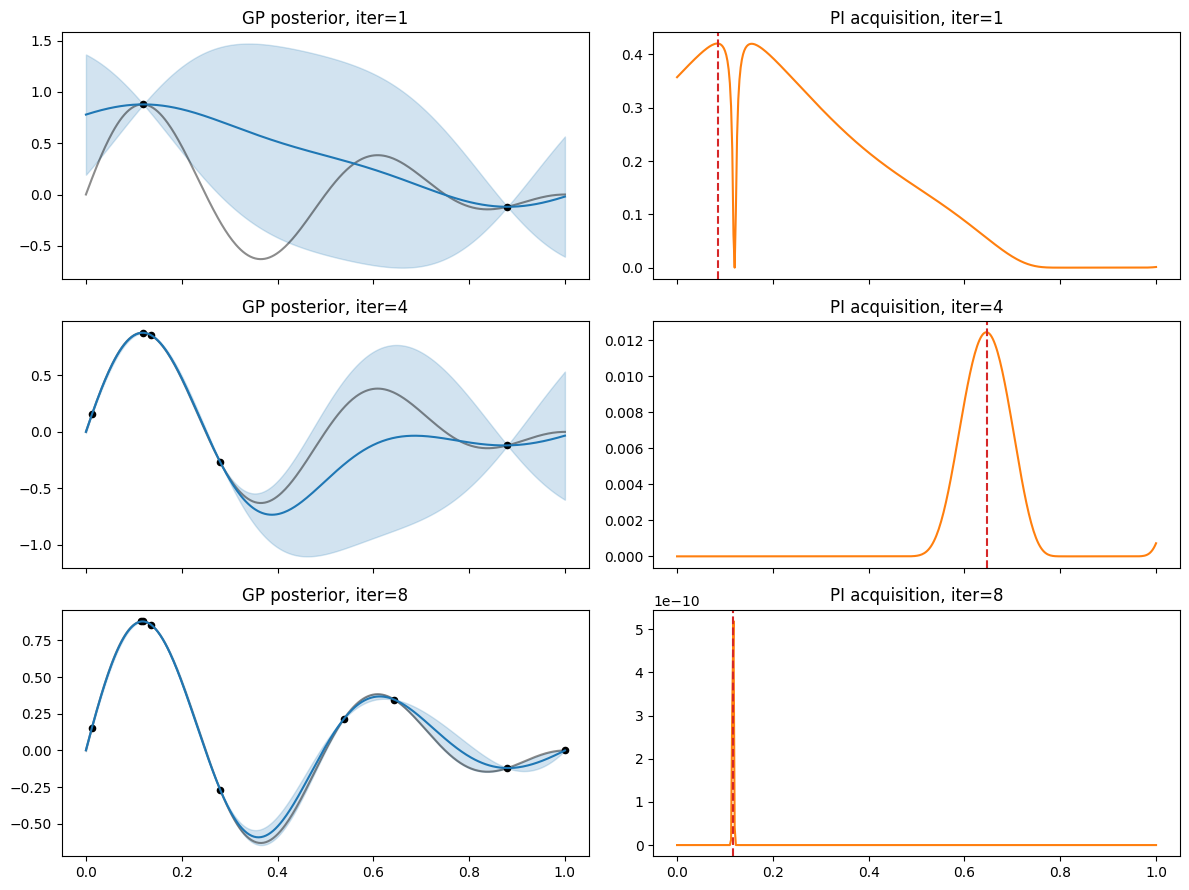

In [21]:
steps_to_show = [0, 3, 7]
fig, axes = plt.subplots(len(steps_to_show), 2, figsize=(12, 9), sharex=True)
for row, step in enumerate(steps_to_show):
    snap = snapshots[step]
    x_seen = snap["x_seen"]
    y_seen = snap["y_seen"]
    mu = snap["mu"]
    std = snap["std"]
    acq = snap["acq_pi"]
    axes[row, 0].plot(x_grid[:, 0], y_true, color="black", alpha=0.45)
    axes[row, 0].plot(x_grid[:, 0], mu, color="tab:blue")
    axes[row, 0].fill_between(x_grid[:, 0], mu - 1.96 * std, mu + 1.96 * std, color="tab:blue", alpha=0.2)
    axes[row, 0].scatter(x_seen[:, 0], y_seen, color="black", s=20)
    axes[row, 0].set_title(f"GP posterior, iter={step + 1}")
    axes[row, 1].plot(x_grid[:, 0], acq, color="tab:orange")
    axes[row, 1].axvline(x_grid[np.argmax(acq), 0], color="tab:red", linestyle="--")
    axes[row, 1].set_title(f"PI acquisition, iter={step + 1}")
plt.tight_layout()
plt.show()



`EI`: Для фиксированной точки $x$ сначала считаем случайное улучшение относительно текущего лучшего значения $f(x^+)$:
$$I_t(x)=\max\big(0, f(x)-f(x^+)-\xi\big).$$
Здесь $\xi \ge 0$ поднимает порог улучшения и усиливает exploration. При GP-постериоре $f(x)\sim\mathcal{N}(\mu_t(x),\sigma_t^2(x))$ acquisition-значение в этой же точке равно математическому ожиданию улучшения:
$$a_{\text{EI}}(x)=\mathbb{E}\left[I_t(x)\right].$$
Для GP это ожидание вычисляется аналитически:
$$a_{\text{EI}}(x)=\left(\mu_t(x)-f(x^+)-\xi\right)\Phi(Z)+\sigma_t(x)\phi(Z), \quad Z=\frac{\mu_t(x)-f(x^+)-\xi}{\sigma_t(x)}.$$
Первый член отвечает за exploitation (насколько среднее уже выше текущего best), второй — за exploration (награда за неопределенность).


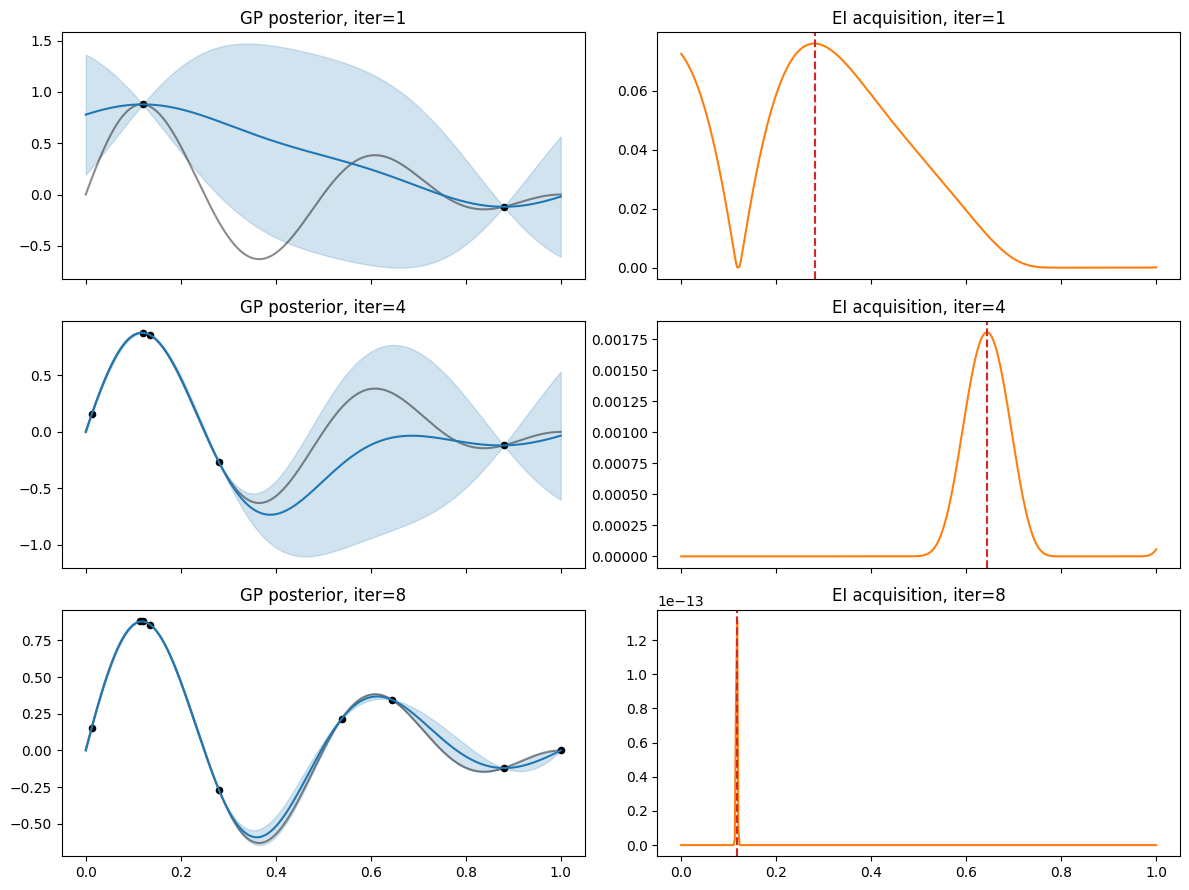

In [22]:
steps_to_show = [0, 3, 7]
fig, axes = plt.subplots(len(steps_to_show), 2, figsize=(12, 9), sharex=True)
for row, step in enumerate(steps_to_show):
    snap = snapshots[step]
    x_seen = snap["x_seen"]
    y_seen = snap["y_seen"]
    mu = snap["mu"]
    std = snap["std"]
    acq = snap["acq_ei"]
    axes[row, 0].plot(x_grid[:, 0], y_true, color="black", alpha=0.45)
    axes[row, 0].plot(x_grid[:, 0], mu, color="tab:blue")
    axes[row, 0].fill_between(x_grid[:, 0], mu - 1.96 * std, mu + 1.96 * std, color="tab:blue", alpha=0.2)
    axes[row, 0].scatter(x_seen[:, 0], y_seen, color="black", s=20)
    axes[row, 0].set_title(f"GP posterior, iter={step + 1}")
    axes[row, 1].plot(x_grid[:, 0], acq, color="tab:orange")
    axes[row, 1].axvline(x_grid[np.argmax(acq), 0], color="tab:red", linestyle="--")
    axes[row, 1].set_title(f"EI acquisition, iter={step + 1}")
plt.tight_layout()
plt.show()


**Задание**: Увеличьте `noise_level` и оцените, как меняется доверительный интервал

In [23]:
categories = ["alt.atheism", "soc.religion.christian"]
class_names = ["atheism", "christian"]

newsgroups_train = fetch_20newsgroups(subset="train", categories=categories)
newsgroups_test = fetch_20newsgroups(subset="test", categories=categories)

X_train_text = newsgroups_train.data
y_train_text = newsgroups_train.target
X_test_text = newsgroups_test.data
y_test_text = newsgroups_test.target


## Random Forest
Проиллюстрируем принцип на датасете **20 Newsgroups**: Рассмотрим двумерное пространство гиперпараметров — два непрерывных параметра `RandomForestClassifier`: `max_samples` (доля объектов в бутстрапе) и `max_features` (доля признаков на разбиении; для float в scikit-learn это доля от числа признаков). Остальные параметры леса зафиксированы для читаемости поверхности. 


In [33]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
)
_text_tr, _text_va, y_tr_m, y_va_m = train_test_split(
    X_train_text,
    y_train_text,
    test_size=0.25,
    stratify=y_train_text,
    random_state=42,
)

_text_tr = _text_tr[:400]
y_tr_m = y_tr_m[:400]

X_tr_m = vectorizer.fit_transform(_text_tr)
X_va_m = vectorizer.transform(_text_va)

RF_N_ESTIMATORS = 40
RF_MAX_DEPTH = 10

max_samples_vals = np.linspace(0.35, 1.0, 16)
max_features_vals = np.linspace(0.1, 0.95, 16)

ms_bounds = (float(max_samples_vals.min()), float(max_samples_vals.max()))
mf_bounds = (float(max_features_vals.min()), float(max_features_vals.max()))


def evaluate_rf(max_samples: float, max_features_frac: float) -> float:
    ms = float(np.clip(max_samples, ms_bounds[0], ms_bounds[1]))
    mf = float(np.clip(max_features_frac, mf_bounds[0], mf_bounds[1]))
    clf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        max_samples=ms,
        max_features=mf,
        random_state=42,
        n_jobs=1,
    )
    clf.fit(X_tr_m, y_tr_m)
    pred = clf.predict(X_va_m)
    return float(accuracy_score(y_va_m, pred))


acc_grid = np.empty((len(max_samples_vals), len(max_features_vals)), dtype=float)
for i, ms in enumerate(max_samples_vals):
    for j, mf in enumerate(max_features_vals):
        acc_grid[i, j] = evaluate_rf(float(ms), float(mf))


def xy_to_norm(ms: np.ndarray, mf: np.ndarray) -> np.ndarray:
    nx = (ms - max_samples_vals[0]) / (max_samples_vals[-1] - max_samples_vals[0] + 1e-12)
    dx = (mf - max_features_vals[0]) / (max_features_vals[-1] - max_features_vals[0] + 1e-12)
    return np.column_stack([nx, dx])


N_grid_pair = np.array(
    np.meshgrid(max_samples_vals, max_features_vals, indexing="ij")
).reshape(2, -1)
X_grid_pair = N_grid_pair.T
X_grid_norm = xy_to_norm(X_grid_pair[:, 0], X_grid_pair[:, 1])

In [45]:
def surrogate_kernel(name: str):
    if name == "rbf":
        return (
            ConstantKernel(1.0, (1e-2, 1e2))
            * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2))
            + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
        )
    if name == "matern15":
        return ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
            length_scale=[1.0, 1.0], nu=1.5
        ) + WhiteKernel(noise_level=1e-5)
    if name == "matern25":
        return ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
            length_scale=[1.0, 1.0], nu=2.5
        ) + WhiteKernel(noise_level=1e-5)
    if name == "exp_sine":
        return (
            ConstantKernel(1.0, (1e-2, 1e2))
            * ExpSineSquared(length_scale=2.0, periodicity=10.0)
            + WhiteKernel(noise_level=1e-5)
        )
    raise ValueError(name)


def gp_predict(
    X_obs: np.ndarray,
    y_obs: np.ndarray,
    X_grid_flat: np.ndarray,
    kernel_name: str,
) -> tuple[np.ndarray, np.ndarray]:
    kernel = surrogate_kernel(kernel_name)
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=4,
        random_state=42,
    )
    gpr.fit(X_obs, y_obs)
    mu, std = gpr.predict(X_grid_flat, return_std=True)
    return mu, std


def propose_next_masked(
    acq_flat: np.ndarray,
    evaluated_flat: set[int],
) -> int:
    mask = np.ones(acq_flat.shape[0], dtype=bool)
    for fi in evaluated_flat:
        mask[fi] = False
    acq = acq_flat.copy()
    acq[~mask] = -np.inf
    return int(np.argmax(acq))


def run_bo_rf(
    acq_kind: str,
    kernel_name: str,
    n_init: int,
    n_bo: int,
    seed: int,
) -> tuple[list[float], list[dict]]:
    rng = np.random.RandomState(seed)
    evaluated_flat: dict[int, float] = {}
    n_n = len(max_samples_vals)
    n_d = len(max_features_vals)
    n_cells = n_n * n_d

    def flat_index(i: int, j: int) -> int:
        return int(i * n_d + j)

    def eval_flat(fi: int) -> float:
        if fi in evaluated_flat:
            return evaluated_flat[fi]
        i, j = divmod(fi, n_d)
        y = evaluate_rf(float(max_samples_vals[i]), float(max_features_vals[j]))
        evaluated_flat[fi] = y
        return y

    best_curve: list[float] = []
    while len(evaluated_flat) < n_init:
        fi = int(rng.randint(n_cells))
        if fi in evaluated_flat:
            continue
        eval_flat(fi)
        best_curve.append(float(max(evaluated_flat.values())))

    snapshots: list[dict] = []
    for _ in range(n_bo):
        ij_list = [divmod(fi, n_d) for fi in evaluated_flat]
        X_obs = xy_to_norm(
            np.array([max_samples_vals[i] for i, _ in ij_list]),
            np.array([max_features_vals[j] for _, j in ij_list]),
        )
        y_obs = np.array([evaluated_flat[flat_index(i, j)] for i, j in ij_list])
        mu, std = gp_predict(X_obs, y_obs, X_grid_norm, kernel_name)
        f_best = float(np.max(y_obs))
        if acq_kind == "ucb":
            acq = acquisition_ucb(mu, std, beta_ucb)
        elif acq_kind == "pi":
            acq = acquisition_pi(mu, std, f_best, xi_acq, eps_acq)
        elif acq_kind == "ei":
            acq = acquisition_ei(mu, std, f_best, xi_acq, eps_acq)
        else:
            raise ValueError(acq_kind)

        acq_2d = acq.reshape(n_n, n_d)
        known_ij = [(i, j) for i, j in ij_list]
        
        fi_next = propose_next_masked(acq, set(evaluated_flat.keys()))
        eval_flat(fi_next)
        best_curve.append(float(max(evaluated_flat.values())))
        snapshots.append(
            {
                "acq": acq_2d,
                "known_ij": known_ij,
                "known_y": y_obs.copy(),
                "acc": float(evaluated_flat[fi_next])
            }
        )

    return best_curve, snapshots


def run_random_rf(n_total: int, seed: int) -> list[float]:
    rng = np.random.RandomState(seed)
    evaluated_flat: dict[int, float] = {}
    n_n = len(max_samples_vals)
    n_d = len(max_features_vals)
    n_cells = n_n * n_d

    def eval_flat(fi: int) -> float:
        if fi in evaluated_flat:
            return evaluated_flat[fi]
        i, j = divmod(fi, n_d)
        y = evaluate_rf(float(max_samples_vals[i]), float(max_features_vals[j]))
        evaluated_flat[fi] = y
        return y

    best_hist: list[float] = []
    y_best = -np.inf
    while len(evaluated_flat) < n_total:
        avail = [fi for fi in range(n_cells) if fi not in evaluated_flat]
        if not avail:
            fi = int(rng.randint(n_cells))
        else:
            fi = int(rng.choice(avail))
        y = eval_flat(fi)
        y_best = max(y_best, y)
        best_hist.append(float(y_best))
    return best_hist


In [ ]:
extent_uv = [
    float(max_features_vals[0]),
    float(max_features_vals[-1]),
    float(max_samples_vals[0]),
    float(max_samples_vals[-1]),
]

def subsample_snaps(snaps: list[dict], max_rows: int = 6) -> list[dict]:
    if len(snaps) <= max_rows:
        return snaps
    idx = np.linspace(0, len(snaps) - 1, max_rows, dtype=int)
    return [snaps[int(k)] for k in idx], idx


def plot_bo_iterations(title: str, snaps: list[dict]) -> None:
    sel, sel_idx = subsample_snaps(snaps, 6)
    fig, axes = plt.subplots(len(sel), 2, figsize=(11, 2.8 * len(sel)))
    if len(sel) == 1:
        axes = np.array([axes])
    for row, snap in enumerate(sel):
        ax_gt, ax_aq = axes[row, 0], axes[row, 1]
        im0 = ax_gt.imshow(
            acc_grid,
            origin="lower",
            aspect="auto",
            extent=extent_uv,
        )
        fig.colorbar(im0, ax=ax_gt, fraction=0.046, pad=0.04)
        im1 = ax_aq.imshow(
            snap["acq"],
            origin="lower",
            aspect="auto",
            extent=extent_uv,
        )
        fig.colorbar(im1, ax=ax_aq, fraction=0.046, pad=0.04)
        ks = snap["known_ij"]
        ax_gt.scatter(
            [float(max_features_vals[j]) for _, j in ks],
            [float(max_samples_vals[i]) for i, _ in ks],
            c="white",
            edgecolors="black",
            s=55,
            zorder=5,
        )
        ax_aq.scatter(
            [float(max_features_vals[j]) for _, j in ks],
            [float(max_samples_vals[i]) for i, _ in ks],
            c="white",
            edgecolors="black",
            s=55,
            zorder=5,
        )
        ax_gt.scatter(
            [float(max_features_vals[j]) for _, j in ks][-1],
            [float(max_samples_vals[i]) for i, _ in ks][-1],
            c="red",
            edgecolors="black",
            s=55,
            zorder=5,
        )
        ax_aq.scatter(
            [float(max_features_vals[j]) for _, j in ks][-1],
            [float(max_samples_vals[i]) for i, _ in ks][-1],
            c="red",
            edgecolors="black",
            s=55,
            zorder=5,
        )
        ax_gt.set_ylabel("max_samples")
        ax_aq.set_ylabel("max_samples")
        if row == len(sel) - 1:
            ax_gt.set_xlabel("max_features")
            ax_aq.set_xlabel("max_features")
        ax_gt.set_title(f"accuracy (GT): current acc {round(snap['acc'], 3)}")
        ax_aq.set_title(f"acquisition: iteration {sel_idx[row]}")
    fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


N_INIT = 5
N_BO = 12
K_BO = "rbf"
SEED_BO = 7

curve_ucb, snap_ucb = run_bo_rf("ucb", K_BO, N_INIT, N_BO, SEED_BO)
plot_bo_iterations(f"GP-UCB (ядро {K_BO})", snap_ucb)


In [ ]:
curve_pi, snap_pi = run_bo_rf("pi", K_BO, N_INIT, N_BO, SEED_BO)
plot_bo_iterations(f"PI (ядро {K_BO})", snap_pi)

In [ ]:
curve_ei, snap_ei = run_bo_rf("ei", K_BO, N_INIT, N_BO, SEED_BO)

plot_bo_iterations(f"EI (ядро {K_BO})", snap_ei)


In [ ]:

n_total = len(curve_ucb)
rand_curve = run_random_rf(n_total, seed=11)

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, n_total + 1), curve_ucb, label="UCB best-so-far")
plt.plot(np.arange(1, n_total + 1), curve_pi, label="PI best-so-far")
plt.plot(np.arange(1, n_total + 1), curve_ei, label="EI best-so-far")
plt.plot(np.arange(1, n_total + 1), rand_curve, label="random best-so-far", linestyle="--")
plt.xlabel("номер оценки (после каждой новой точки)")
plt.ylabel("лучшая accuracy")
plt.legend()
plt.title("Накопленный максимум: BO (UCB / PI / EI) vs random")
plt.tight_layout()
plt.show()

# Optuna
На практике мы редко оптимизируем «идеальную» гладкую функцию. Мы оптимизируем пайплайн обучения, где есть шум, ограниченный бюджет и смешанные типы параметров.

`Optuna` по умолчанию использует TPE (Tree-structured Parzen Estimator) — это sequential model-based подход, который моделирует не $p(y \mid x)$, а плотности $p(x \mid y \in \mathcal{L})$ и $p(x \mid y \in \mathcal{H})$ для «хороших» и «плохих» областей значений.

Интуиция TPE:
- после нескольких запусков алгоритм отделяет удачные и неудачные конфигурации;
- новые точки выбираются так, чтобы чаще попадать в области, похожие на удачные;
- при том же бюджете это обычно эффективнее чисто случайного поиска.


Теоретическая база TPE и альтернативных суррогатов: [RBC Borealis](https://rbcborealis.com/research-blogs/tutorial-8-bayesian-optimization/), [AAAI slides](https://bayesopt-tutorial.github.io/syllabus/fullslides.pdf), [Distill](https://distill.pub/2020/bayesian-optimization/).

In [2]:
X_svc, y_svc = make_classification(
    n_samples=1200,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    class_sep=1.2,
    flip_y=0.04,
    random_state=42,
)

X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
    X_svc,
    y_svc,
    test_size=0.25,
    stratify=y_svc,
    random_state=42,
)

svc_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42)),
])

grid_params = {
    "model__C": np.logspace(-2, 2, 6),
    "model__gamma": np.logspace(-3, 0, 6),
}

grid_cv = GridSearchCV(
    svc_pipe,
    param_grid=grid_params,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
)
grid_cv.fit(X_train_svc, y_train_svc)

grid_scores = np.array(grid_cv.cv_results_["mean_test_score"])
grid_best_curve = np.maximum.accumulate(grid_scores)

In [3]:
random_cv = RandomizedSearchCV(
    svc_pipe,
    param_distributions={
        "model__C": np.logspace(-2, 2, 80),
        "model__gamma": np.logspace(-3, 0, 80),
    },
    n_iter=36,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
)
random_cv.fit(X_train_svc, y_train_svc)

random_scores = np.array(random_cv.cv_results_["mean_test_score"])
random_best_curve = np.maximum.accumulate(random_scores)

def objective_svc(trial: "optuna.trial.Trial") -> float:
    c_value = trial.suggest_float("C", 1e-2, 1e2, log=True)
    gamma_value = trial.suggest_float("gamma", 1e-3, 1.0, log=True)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=c_value, gamma=gamma_value, probability=True, random_state=42)),
    ])
    score = cross_val_score(model, X_train_svc, y_train_svc, scoring="roc_auc", cv=3, n_jobs=-1).mean()
    return float(score)

study_svc = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_svc.optimize(objective_svc, n_trials=36, show_progress_bar=False)

optuna_scores = np.array([t.value for t in study_svc.trials])
optuna_best_curve = np.maximum.accumulate(optuna_scores)

[I 2026-05-02 02:47:45,905] A new study created in memory with name: no-name-70707a3d-bbd6-4c2d-a87b-6fb9a2a04b79
[I 2026-05-02 02:47:46,464] Trial 0 finished with value: 0.8626622549479565 and parameters: {'C': 0.31489116479568624, 'gamma': 0.711447600934342}. Best is trial 0 with value: 0.8626622549479565.
[I 2026-05-02 02:47:46,895] Trial 1 finished with value: 0.958798594176202 and parameters: {'C': 8.471801418819979, 'gamma': 0.06251373574521749}. Best is trial 1 with value: 0.958798594176202.
[I 2026-05-02 02:47:47,401] Trial 2 finished with value: 0.8067790436776615 and parameters: {'C': 0.04207988669606638, 'gamma': 0.0029375384576328283}. Best is trial 1 with value: 0.958798594176202.
[I 2026-05-02 02:47:47,883] Trial 3 finished with value: 0.9173307416132075 and parameters: {'C': 0.017073967431528128, 'gamma': 0.39676050770529875}. Best is trial 1 with value: 0.958798594176202.
[I 2026-05-02 02:47:48,415] Trial 4 finished with value: 0.9611689869343988 and parameters: {'C': 2

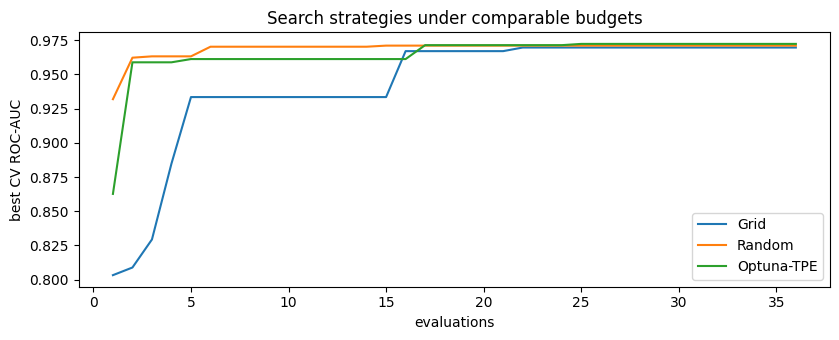

In [4]:
summary_svc = pd.DataFrame({
    "method": ["GridSearchCV", "RandomizedSearchCV", "Optuna-TPE"],
    "best_cv_roc_auc": [grid_cv.best_score_, random_cv.best_score_, study_svc.best_value],
})
summary_svc

plt.figure(figsize=(8.5, 3.5))
plt.plot(np.arange(1, len(grid_best_curve) + 1), grid_best_curve, label="Grid")
plt.plot(np.arange(1, len(random_best_curve) + 1), random_best_curve, label="Random")
plt.plot(np.arange(1, len(optuna_best_curve) + 1), optuna_best_curve, label="Optuna-TPE")
plt.xlabel("evaluations")
plt.ylabel("best CV ROC-AUC")
plt.title("Search strategies under comparable budgets")
plt.legend()
plt.tight_layout()
plt.show()

**Задание**: Добавьте `MedianPruner` и оцените ускорение подбора. 

**Задание**: Измените search space (`linear` vs `log`) и сравните итоговое качество.

Для более сложной демонстрации используем **20 Newsgroups** в той же постановке, что и в ноутбуке по интерпретации: две категории (`alt.atheism`, `soc.religion.christian`). Пайплайн:

1. `TfidfVectorizer(lowercase=False)` 
2. `RandomForestClassifier`
3. Подбор гиперпараметров через `Optuna` по среднему macro-F1 на кросс-валидации **обучающей** выборки;
4. Итоговое сравнение baseline и настроенной модели — на официальном **тестовом** сплите.


In [8]:
# Корпуса train/test и метки уже заданы в ячейке загрузки 20 Newsgroups выше (перед разделом «Random Forest»).


In [9]:
cv_text = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

baseline_text_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(lowercase=False)),
        ("clf", RandomForestClassifier(random_state=42)),
    ]
)
baseline_text_model.fit(X_train_text, y_train_text)
y_pred_base = baseline_text_model.predict(X_test_text)
baseline_f1 = f1_score(y_test_text, y_pred_base, average="macro")




[I 2026-05-02 02:49:45,733] A new study created in memory with name: no-name-dcc456e4-23c6-44e0-95fa-81111fffe732
[I 2026-05-02 02:49:48,532] Trial 0 finished with value: 0.9042034909087323 and parameters: {'ngram_hi': 1, 'max_features': None, 'min_df': 1, 'n_estimators': 64, 'max_depth': 36, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.9042034909087323.
[I 2026-05-02 02:49:53,550] Trial 1 finished with value: 0.9183156049150353 and parameters: {'ngram_hi': 2, 'max_features': 5000, 'min_df': 1, 'n_estimators': 96, 'max_depth': 15, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.9183156049150353.
[I 2026-05-02 02:49:57,176] Trial 2 finished with value: 0.9438049408898156 and parameters: {'ngram_hi': 1, 'max_features': 5000, 'min_df': 2, 'n_estimators': 164, 'max_depth': 33, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.9438049408898156.
[I 2026-05-02 02:50:03,657] Trial 3 finished with value: 0.9093901289118733 and parameters: {'ngram_hi': 2, 'max_features': 10000

In [ ]:
def objective_text(trial: "optuna.trial.Trial") -> float:
    ngram_hi = trial.suggest_int("ngram_hi", 1, 2)
    max_features = trial.suggest_categorical("max_features", [None, 5000, 10000, 20000])
    min_df = trial.suggest_int("min_df", 1, 5)
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 5, 40)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    model = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=False,
                    ngram_range=(1, ngram_hi),
                    max_features=max_features,
                    min_df=min_df,
                ),
            ),
            (
                "clf",
                RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    )
    scores = cross_val_score(
        model,
        X_train_text,
        y_train_text,
        scoring="f1_macro",
        cv=cv_text,
        n_jobs=-1,
    )
    return float(scores.mean())



In [ ]:

study_text = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study_text.optimize(objective_text, n_trials=35, show_progress_bar=False)

best_params_text = study_text.best_params

best_text_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=False,
                ngram_range=(1, best_params_text["ngram_hi"]),
                max_features=best_params_text["max_features"],
                min_df=best_params_text["min_df"],
            ),
        ),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=best_params_text["n_estimators"],
                max_depth=best_params_text["max_depth"],
                min_samples_leaf=best_params_text["min_samples_leaf"],
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
best_text_model.fit(X_train_text, y_train_text)
y_pred_tuned = best_text_model.predict(X_test_text)
tuned_f1 = f1_score(y_test_text, y_pred_tuned, average="macro")

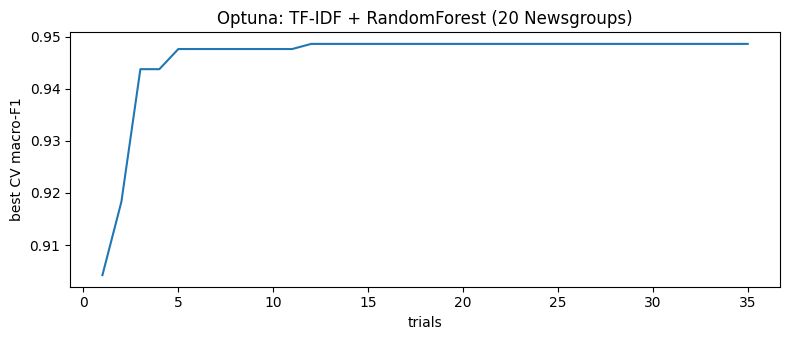

In [10]:
pd.DataFrame({
    "model": ["baseline", "optuna_tuned"],
    "test_macro_f1": [baseline_f1, tuned_f1],
})

plt.figure(figsize=(8, 3.5))
plt.plot(np.arange(1, len(study_text.trials) + 1), np.maximum.accumulate([t.value for t in study_text.trials]))
plt.xlabel("trials")
plt.ylabel("best CV macro-F1")
plt.title("Optuna: TF-IDF + RandomForest (20 Newsgroups)")
plt.tight_layout()
plt.show()

Краткая интерпретация результатов текстового кейса:

- если `optuna_tuned` дает прирост на тесте, оптимизация подобрала более удачную связку **TF-IDF** (n-граммы, `max_features`, `min_df`) и **Random Forest**;
- если CV «шумный», а тест плоский, это нормально: дисбаланс, дрейф и шум; попробуйте больше фолдов CV или сузить search space;
- если прирост небольшой, базовая модель уже может быть близка к разумному качеству для этого поднабора 20 Newsgroups.

**Задание.** Сравните пайплайн `TF-IDF + RandomForest` (как выше) с вариантом на **sentence embeddings** (и классификатором по эмбеддингам) на тех же train/test сплитах 20 Newsgroups.